# Entrenamiento y Evaluación de Modelos - EnergiAI

Entrenar, evaluar y serializar el modelo de clasificación energética

### 1. Configuración inicial y carga de datos

In [3]:
# Importar librerías y configurar entorno
import os
import sys
import warnings
import json
import time
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from xgboost import XGBClassifier

# Para balanceo de clases (opcional)
#from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("Set2")
%matplotlib inline

In [4]:
# Cargar dataset extendido

# Rutas
DATA_PATH   = '../data/processed/dataset_extendido.csv'
MODELS_PATH = '../models/saved/'
# OUTPUT_IMAGES_PATH = '../images/modelos_extendido/'

os.makedirs(MODELS_PATH, exist_ok=True)
#os.makedirs(OUTPUT_IMAGES_PATH, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Dataset extendido cargado correctamente.")
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas.")
print("\nPrimeras 5 filas:")
display(df.head())

Dataset extendido cargado correctamente.
Dimensiones: 3000 filas, 10 columnas.

Primeras 5 filas:


,consumo_kwh,cantidad_equipos,horas_alto_consumo,tipo_inmueble,uso_horario_pico,numero_habitantes,antiguedad_inmueble,calefaccion,aire_acondicionado,categoria
0,1128,13,2,Casa,True,6,44,True,False,Moderado
1,1500,12,9,Local,True,4,46,False,True,Ineficiente
2,1348,6,6,Oficina,True,1,26,True,False,Moderado
3,241,19,10,Apartamento,False,3,11,True,False,Moderado
4,546,20,3,Apartamento,False,3,12,False,False,Eficiente


In [5]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   consumo_kwh          3000 non-null   int64
 1   cantidad_equipos     3000 non-null   int64
 2   horas_alto_consumo   3000 non-null   int64
 3   tipo_inmueble        3000 non-null   str  
 4   uso_horario_pico     3000 non-null   bool 
 5   numero_habitantes    3000 non-null   int64
 6   antiguedad_inmueble  3000 non-null   int64
 7   calefaccion          3000 non-null   bool 
 8   aire_acondicionado   3000 non-null   bool 
 9   categoria            3000 non-null   str  
dtypes: bool(3), int64(5), str(2)
memory usage: 173.0 KB


### 2. Análisis exploratorio rápido

Distribución de la variable objetivo:
categoria
Moderado       2202
Ineficiente     638
Eficiente       160
Name: count, dtype: int64

Proporciones:
categoria
Moderado       0.734
Ineficiente    0.213
Eficiente      0.053
Name: proportion, dtype: float64


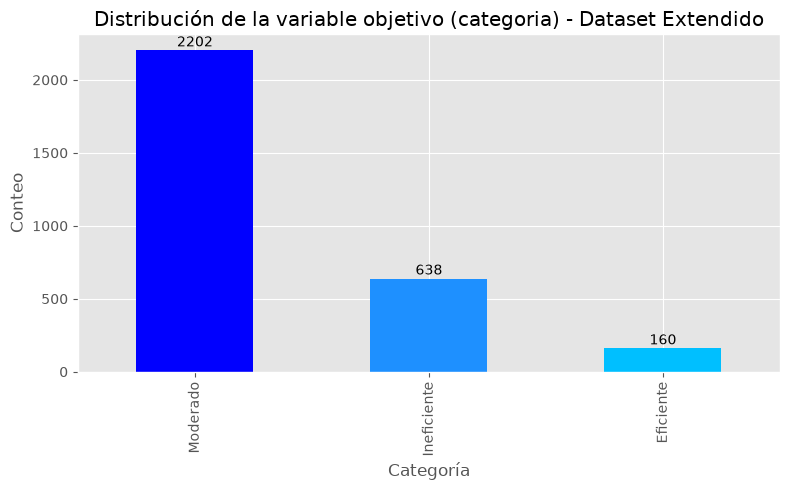

In [6]:
#  Distribución de la variable objetivo

print("Distribución de la variable objetivo:")
print(df['categoria'].value_counts())
print(f"\nProporciones:\n{df['categoria'].value_counts(normalize=True).round(3)}")

# Gráfico de barras
fig, ax = plt.subplots(figsize=(8, 5))
df['categoria'].value_counts().plot(kind='bar', ax=ax, color=['blue', 'dodgerblue', 'deepskyblue'])
ax.set_title('Distribución de la variable objetivo (categoria) - Dataset Extendido')
ax.set_xlabel('Categoría')
ax.set_ylabel('Conteo')

for i, v in enumerate(df['categoria'].value_counts()):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
# plt.savefig(f'{OUTPUT_IMAGES_PATH}/distribucion_categoria_extendido.png', dpi=150, bbox_inches='tight')
plt.show()

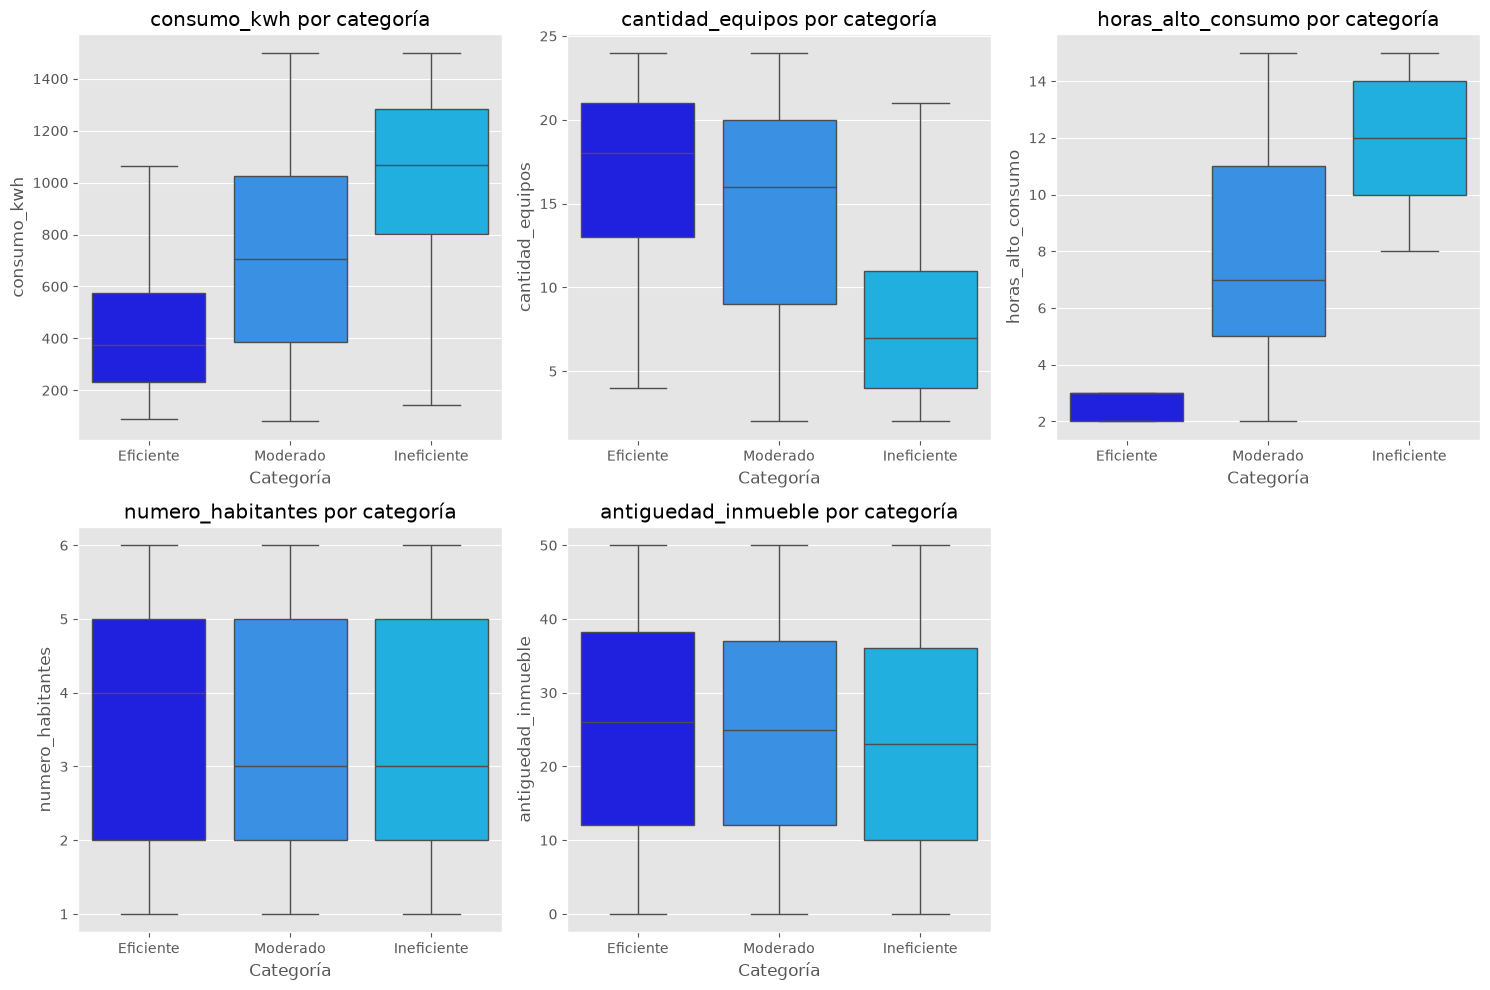

In [7]:
# Boxplots de variables numéricas por categoría

num_cols = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 
            'numero_habitantes', 'antiguedad_inmueble']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='categoria', y=col, ax=axes[i], 
                order=['Eficiente', 'Moderado', 'Ineficiente'], palette=['blue', 'dodgerblue', 'deepskyblue'])
    axes[i].set_title(f'{col} por categoría')
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel(col)

# Ocultar el subplot sobrante
if len(num_cols) < len(axes):
    for j in range(len(num_cols), len(axes)):
        axes[j].axis('off')

plt.tight_layout()
# plt.savefig(f'{OUTPUT_IMAGES_PATH}/boxplots_num_por_categoria_extendido.png', dpi=150, bbox_inches='tight')
plt.show()

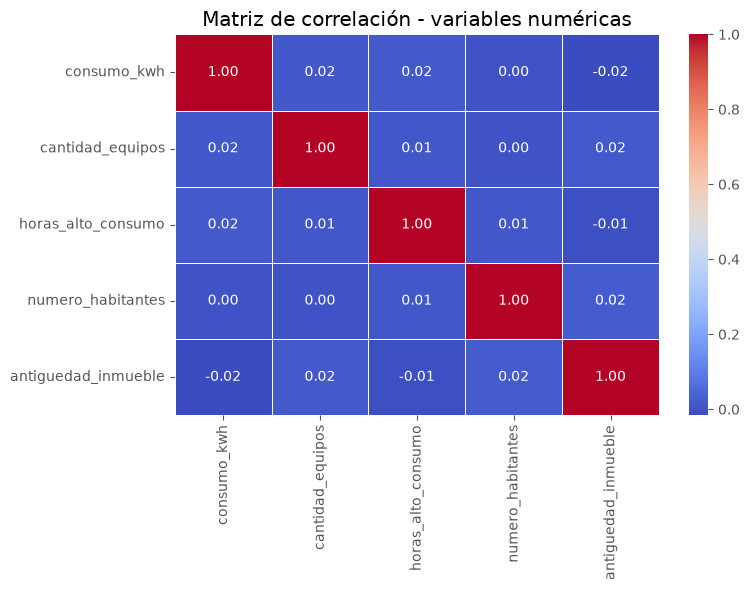

In [8]:
# Matriz de correlación entre variables numéricas

corr_cols = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 
             'numero_habitantes', 'antiguedad_inmueble']

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación - variables numéricas')
plt.tight_layout()
# plt.savefig(f'{OUTPUT_IMAGES_PATH}/matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Variables categóricas y valores únicos

cat_cols = ['tipo_inmueble', 'uso_horario_pico', 'calefaccion', 'aire_acondicionado']

print("Variables categóricas y sus valores únicos:")
for col in cat_cols:
    print(f"\n Variable: {col}:")
    print(f"   Valores únicos: {df[col].unique()}")
    print(f"   Frecuencias:\n{df[col].value_counts()}")

Variables categóricas y sus valores únicos:

 Variable: tipo_inmueble:
   Valores únicos: <StringArray>
['Casa', 'Local', 'Oficina', 'Apartamento']
Length: 4, dtype: str
   Frecuencias:
tipo_inmueble
Casa           1179
Apartamento     903
Local           498
Oficina         420
Name: count, dtype: int64

 Variable: uso_horario_pico:
   Valores únicos: [ True False]
   Frecuencias:
uso_horario_pico
False    1656
True     1344
Name: count, dtype: int64

 Variable: calefaccion:
   Valores únicos: [ True False]
   Frecuencias:
calefaccion
False    1925
True     1075
Name: count, dtype: int64

 Variable: aire_acondicionado:
   Valores únicos: [False  True]
   Frecuencias:
aire_acondicionado
False    1768
True     1232
Name: count, dtype: int64


### 3. Preprocesamiento de datos

In [10]:
# Definir características (X) y objetivo (y)
X = df.drop(columns=['categoria'])
y = df['categoria']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Características (X):")
print(f"Dimensiones: {X.shape}")
print(f"Columnas: {X.columns.tolist()}")

print("\nVariable objetivo (y):")
print(f"Dimensiones: {y.shape}")
print(f"Distribución:\n{y.value_counts()}")

print("\nVariable objetivo (y) codificada:")
print(f"Dimensiones: {y_encoded.shape}")
print(f"Clases originales: {label_encoder.classes_}")
print(f"Distribución de clases codificadas:\n{pd.Series(y_encoded).value_counts().sort_index()}")

Características (X):
Dimensiones: (3000, 9)
Columnas: ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 'tipo_inmueble', 'uso_horario_pico', 'numero_habitantes', 'antiguedad_inmueble', 'calefaccion', 'aire_acondicionado']

Variable objetivo (y):
Dimensiones: (3000,)
Distribución:
categoria
Moderado       2202
Ineficiente     638
Eficiente       160
Name: count, dtype: int64

Variable objetivo (y) codificada:
Dimensiones: (3000,)
Clases originales: ['Eficiente' 'Ineficiente' 'Moderado']
Distribución de clases codificadas:
0     160
1     638
2    2202
Name: count, dtype: int64


In [11]:
# Codificación de variables categóricas

# Identificar columnas categóricas
cat_cols = ['tipo_inmueble', 'uso_horario_pico', 'calefaccion', 'aire_acondicionado']
num_cols = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 'numero_habitantes', 'antiguedad_inmueble']

# Crear un preprocesador que:
# - Aplica OneHotEncoder a 'tipo_inmueble' (nominal)
# - Aplica OneHotEncoder a las binarias (uso_horario_pico, calefaccion, aire_acondicionado)
# - Dejar las numéricas sin cambios (se escalarán después)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'  # Mantiene las columnas numéricas sin cambios
)

# Aplicar el preprocesador a X
X_encoded = preprocessor.fit_transform(X)

# Obtener nombres de las columnas después de OneHot
feature_names = preprocessor.get_feature_names_out()
print("Nombres de características después de codificación:")
print(feature_names)
print(f"\nDimensiones de X_encoded: {X_encoded.shape}")

Nombres de características después de codificación:
['cat__tipo_inmueble_Casa' 'cat__tipo_inmueble_Local'
 'cat__tipo_inmueble_Oficina' 'cat__uso_horario_pico_True'
 'cat__calefaccion_True' 'cat__aire_acondicionado_True'
 'remainder__consumo_kwh' 'remainder__cantidad_equipos'
 'remainder__horas_alto_consumo' 'remainder__numero_habitantes'
 'remainder__antiguedad_inmueble']

Dimensiones de X_encoded: (3000, 11)


In [12]:
# Escalado de variables numéricas

# Seleccionar columnas numéricas originales (sin codificar)
num_cols_original = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 
                     'numero_habitantes', 'antiguedad_inmueble']

# Crear y ajustar el escalador
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[:, -len(num_cols_original):] = scaler.fit_transform(X_encoded[:, -len(num_cols_original):])

print("Variables numéricas escaladas:")
print(f"Media de consumo_kwh después de escalar: {X_scaled[:, -len(num_cols_original):][:, 0].mean():.2f}")
print(f"Desviación estándar de consumo_kwh: {X_scaled[:, -len(num_cols_original):][:, 0].std():.2f}")
print("\nPrimeras 5 filas del dataset preprocesado:")
print(X_scaled[:5])

Variables numéricas escaladas:
Media de consumo_kwh después de escalar: -0.00
Desviación estándar de consumo_kwh: 1.00

Primeras 5 filas del dataset preprocesado:
[[ 1.          0.          0.          1.          1.          0.
   0.89313012 -0.06513932 -1.60918011  1.4701336   1.30987907]
 [ 0.          1.          0.          1.          0.          1.
   1.82702614 -0.21511473  0.13739743  0.30582505  1.44520648]
 [ 0.          0.          1.          1.          1.          0.
   1.44543422 -1.11496717 -0.6111358  -1.44063779  0.09193242]
 [ 0.          0.          0.          0.          1.          0.
  -1.33365958  0.83471313  0.38690851 -0.27632923 -0.92302313]
 [ 0.          0.          0.          0.          0.          0.
  -0.56796527  0.98468854 -1.35966903 -0.27632923 -0.85535943]]


In [13]:
# Dividir manteniendo la proporción de clases (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("División de datos completada:")
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")
#print(f"\nDistribución en entrenamiento:\n{y_train.value_counts()}")
#print(f"\nDistribución en prueba:\n{y_test.value_counts()}")
print(f"\nDistribución en entrenamiento (codificado):\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"\nDistribución en prueba (codificado):\n{pd.Series(y_test).value_counts().sort_index()}")

División de datos completada:
Entrenamiento: 2400 muestras
Prueba: 600 muestras

Distribución en entrenamiento (codificado):
0     128
1     510
2    1762
Name: count, dtype: int64

Distribución en prueba (codificado):
0     32
1    128
2    440
Name: count, dtype: int64


In [14]:
# Guardar el escalador, preprocesador, feature_names y label_encoder
joblib.dump(scaler, f'{MODELS_PATH}/scaler.pkl')
joblib.dump(preprocessor, f'{MODELS_PATH}/preprocessor.pkl')
joblib.dump(feature_names, f'{MODELS_PATH}/feature_names.pkl')
joblib.dump(label_encoder, f'{MODELS_PATH}/label_encoder.pkl')

print("Preprocesadores guardados en:", MODELS_PATH)
print(f"   - scaler.pkl: {scaler.__class__.__name__}")
print(f"   - preprocessor.pkl: {preprocessor.__class__.__name__}")
print(f"   - feature_names.pkl: {len(feature_names)} características")
print(f"   - label_encoder.pkl: {label_encoder.__class__.__name__} (clases: {label_encoder.classes_})")

Preprocesadores guardados en: ../models/saved/
   - scaler.pkl: StandardScaler
   - preprocessor.pkl: ColumnTransformer
   - feature_names.pkl: 11 características
   - label_encoder.pkl: LabelEncoder (clases: ['Eficiente' 'Ineficiente' 'Moderado'])


In [15]:
scaler = joblib.load("../models/saved/scaler.pkl")
preprocessor = joblib.load("../models/saved/preprocessor.pkl")
feature_names = joblib.load("../models/saved/feature_names.pkl")
label_encoder = joblib.load("../models/saved/label_encoder.pkl")

In [16]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [17]:
feature_names

array(['cat__tipo_inmueble_Casa', 'cat__tipo_inmueble_Local',
       'cat__tipo_inmueble_Oficina', 'cat__uso_horario_pico_True',
       'cat__calefaccion_True', 'cat__aire_acondicionado_True',
       'remainder__consumo_kwh', 'remainder__cantidad_equipos',
       'remainder__horas_alto_consumo', 'remainder__numero_habitantes',
       'remainder__antiguedad_inmueble'], dtype=object)

In [18]:
scaler

StandardScaler()

In [19]:
label_encoder

Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[object](3,)","['Eficiente','Ineficiente','Moderado']"


### 4. Entrenamiento de modelos base

In [20]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=3)
}

trained_models = {}

print("Entrenando modelos...")
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    trained_models[name] = model
    print(f"{name} entrenado en {end - start:.2f} segundos")

Entrenando modelos...
Logistic Regression entrenado en 0.10 segundos
Decision Tree entrenado en 0.01 segundos
Random Forest entrenado en 0.51 segundos
XGBoost entrenado en 1.35 segundos



Modelo: Logistic Regression
   Accuracy: 0.8783
   F1-score (weighted): 0.8840

   Classification Report:
              precision    recall  f1-score   support

   Eficiente       0.57      1.00      0.73        32
 Ineficiente       0.75      0.92      0.83       128
    Moderado       0.97      0.86      0.91       440

    accuracy                           0.88       600
   macro avg       0.77      0.93      0.82       600
weighted avg       0.91      0.88      0.88       600



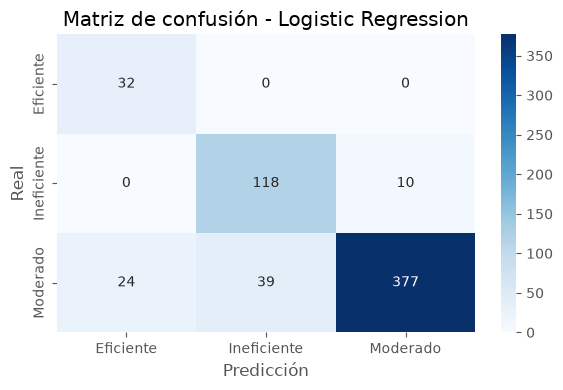


Modelo: Decision Tree
   Accuracy: 0.9767
   F1-score (weighted): 0.9765

   Classification Report:
              precision    recall  f1-score   support

   Eficiente       0.97      0.91      0.94        32
 Ineficiente       0.98      0.95      0.96       128
    Moderado       0.98      0.99      0.98       440

    accuracy                           0.98       600
   macro avg       0.97      0.95      0.96       600
weighted avg       0.98      0.98      0.98       600



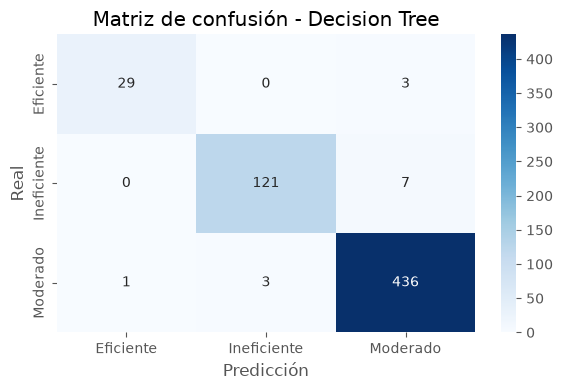


Modelo: Random Forest
   Accuracy: 0.9767
   F1-score (weighted): 0.9767

   Classification Report:
              precision    recall  f1-score   support

   Eficiente       0.91      0.94      0.92        32
 Ineficiente       0.97      0.96      0.96       128
    Moderado       0.98      0.98      0.98       440

    accuracy                           0.98       600
   macro avg       0.95      0.96      0.96       600
weighted avg       0.98      0.98      0.98       600



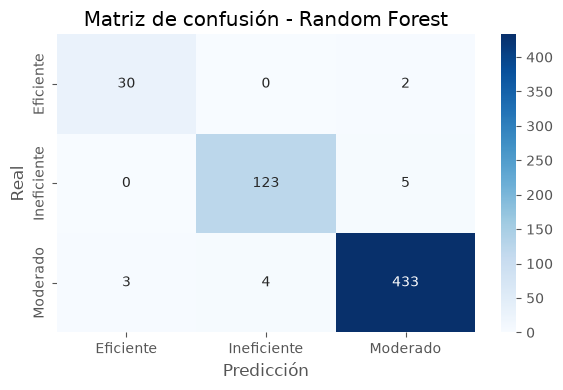


Modelo: XGBoost
   Accuracy: 0.9783
   F1-score (weighted): 0.9780

   Classification Report:
              precision    recall  f1-score   support

   Eficiente       1.00      0.84      0.92        32
 Ineficiente       0.97      0.97      0.97       128
    Moderado       0.98      0.99      0.99       440

    accuracy                           0.98       600
   macro avg       0.98      0.93      0.96       600
weighted avg       0.98      0.98      0.98       600



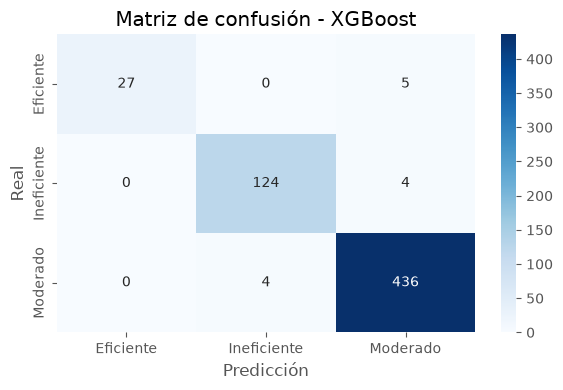

In [21]:
# Evaluación de modelos

results = {}

for name, model in trained_models.items():
    # Predicciones
    y_pred = model.predict(X_test)
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Resultados
    results[name] = {
        'accuracy': acc,
        'f1_weighted': f1,
        'y_pred': y_pred
    }
    
    print(f"\nModelo: {name}")
    print(f"   Accuracy: {acc:.4f}")
    print(f"   F1-score (weighted): {f1:.4f}")
    print("\n   Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Matriz de confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.tight_layout()
    # plt.savefig(f'{OUTPUT_IMAGES_PATH}/confusion_{name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

Comparación de modelos:
             Modelo  Accuracy  F1-score (weighted)
Logistic Regression  0.878333             0.884044
      Decision Tree  0.976667             0.976506
      Random Forest  0.976667             0.976701
            XGBoost  0.978333             0.978041


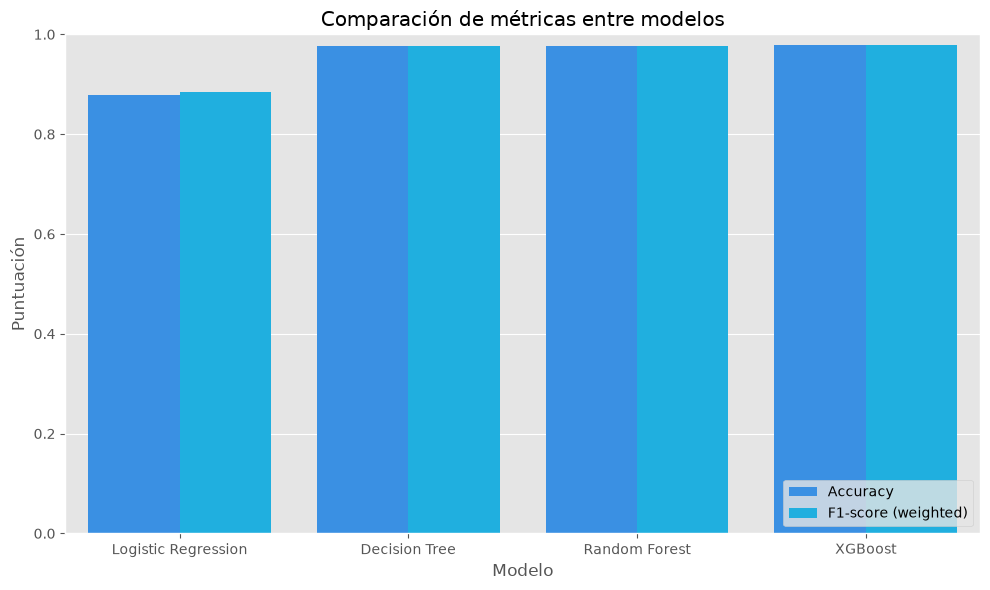


 >>> Mejor modelo: XGBoost con F1-score = 0.9780


In [22]:
# Comparación de modelos

comparison_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'F1-score (weighted)': [results[m]['f1_weighted'] for m in results]
})

print("Comparación de modelos:")
print(comparison_df.to_string(index=False))

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df_melted = comparison_df.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

sns.barplot(data=comparison_df_melted, x='Modelo', y='Valor', hue='Métrica', palette=['dodgerblue', 'deepskyblue'])
ax.set_title('Comparación de métricas entre modelos')
ax.set_ylim(0, 1)
ax.set_ylabel('Puntuación')
ax.set_xlabel('Modelo')
plt.legend(loc='lower right')
plt.tight_layout()
# plt.savefig(f'{OUTPUT_IMAGES_PATH}/comparacion_modelos_base.png', dpi=150, bbox_inches='tight')
plt.show()

# Identificar el mejor modelo
best_model_name = comparison_df.loc[comparison_df['F1-score (weighted)'].idxmax(), 'Modelo']
best_f1 = comparison_df['F1-score (weighted)'].max()
print(f"\n >>> Mejor modelo: {best_model_name} con F1-score = {best_f1:.4f}")

### 5. Serialización de modelos

In [23]:
# Guardar cada modelo entrenado
for name, model in trained_models.items():
    safe_name = name.replace(' ', '_').lower()
    file_path = f'{MODELS_PATH}/{safe_name}_model.pkl'
    joblib.dump(model, file_path)
    print(f"Modelo '{name}' guardado en: {file_path}")

# Guardar los preprocesadores 
joblib.dump(scaler, f'{MODELS_PATH}/scaler.pkl')
joblib.dump(preprocessor, f'{MODELS_PATH}/preprocessor.pkl')
joblib.dump(feature_names, f'{MODELS_PATH}/feature_names.pkl')
joblib.dump(label_encoder, f'{MODELS_PATH}/label_encoder.pkl')
print("\nPreprocesadores guardados/actualizados.")

# Archivo de metadatos con resultados y configuración
metadata = {
    'timestamp': datetime.now(timezone.utc).astimezone().isoformat(),
    'dataset': 'dataset_extendido.csv',
    'num_samples': len(df),
    'num_features': X_scaled.shape[1],
    'feature_names': feature_names.tolist(),
    'classes': label_encoder.classes_.tolist(),
    'models': {}
}

for name, result in results.items():
    metadata['models'][name] = {
        'accuracy': result['accuracy'],
        'f1_weighted': result['f1_weighted'],
        'params': trained_models[name].get_params() if hasattr(trained_models[name], 'get_params') else None
    }

# Guardar metadatos en JSON
with open(f'{MODELS_PATH}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\nMetadatos guardados en: {MODELS_PATH}/model_metadata.json")

Modelo 'Logistic Regression' guardado en: ../models/saved//logistic_regression_model.pkl
Modelo 'Decision Tree' guardado en: ../models/saved//decision_tree_model.pkl
Modelo 'Random Forest' guardado en: ../models/saved//random_forest_model.pkl
Modelo 'XGBoost' guardado en: ../models/saved//xgboost_model.pkl

Preprocesadores guardados/actualizados.

Metadatos guardados en: ../models/saved//model_metadata.json


##### Prueba de inferencia

In [24]:
# Cargar un modelo específico
models = ('logistic_regression', 'decision_tree', 'random_forest', 'xgboost')
model_name = models[3]
model_path = f'{MODELS_PATH}/{model_name}_model.pkl'

# Cargar modelo y preprocesadores
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(f'{MODELS_PATH}/scaler.pkl')
loaded_preprocessor = joblib.load(f'{MODELS_PATH}/preprocessor.pkl')
loaded_label_encoder = joblib.load(f'{MODELS_PATH}/label_encoder.pkl')
loaded_feature_names = joblib.load(f'{MODELS_PATH}/feature_names.pkl')

print(f"Modelo '{model_name}' y preprocesadores cargados correctamente.")

Modelo 'xgboost' y preprocesadores cargados correctamente.


In [25]:
# Ejemplo de entrada (simulando un usuario)
ejemplo = pd.DataFrame([{
    'consumo_kwh'           : 600,
    'cantidad_equipos'      : 12,
    'horas_alto_consumo'    : 6,
    'tipo_inmueble'         : 'Casa',
    'uso_horario_pico'      : True,
    'numero_habitantes'     : 4,
    'antiguedad_inmueble'   : 20,
    'calefaccion'           : False,
    'aire_acondicionado'    : True
}])

print("\nDatos de ejemplo (entrada del usuario):")
display(ejemplo)

# Aplicar preprocesamiento
ejemplo_encoded = loaded_preprocessor.transform(ejemplo)
ejemplo_scaled = ejemplo_encoded.copy()

# Las columnas numéricas están al final (remainder)
num_cols_original = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 
                     'numero_habitantes', 'antiguedad_inmueble']
num_indices = [-len(num_cols_original) + i for i in range(len(num_cols_original))]
ejemplo_scaled[:, num_indices] = loaded_scaler.transform(ejemplo_encoded[:, num_indices])

# Predicción
prediccion_encoded = loaded_model.predict(ejemplo_scaled)
prediccion = loaded_label_encoder.inverse_transform(prediccion_encoded)
probabilidad = loaded_model.predict_proba(ejemplo_scaled)

print("\nResultado de la predicción:")
print(f"Categoría predicha: {prediccion[0]}")
print("Probabilidades por clase:")
for i, cls in enumerate(loaded_label_encoder.classes_):
    print(f"   {cls}: {probabilidad[0][i]:.4f}")


salida_json = {
    "categoria": prediccion[0],
    "probabilidad": float(max(probabilidad[0])),
    "distancias": {
        cls: float(probabilidad[0][i]) for i, cls in enumerate(loaded_label_encoder.classes_)
    }
}
print("\nSalida JSON simulada para la API:")
print(json.dumps(salida_json, indent=2))



Datos de ejemplo (entrada del usuario):


,consumo_kwh,cantidad_equipos,horas_alto_consumo,tipo_inmueble,uso_horario_pico,numero_habitantes,antiguedad_inmueble,calefaccion,aire_acondicionado
0,600,12,6,Casa,True,4,20,False,True



Resultado de la predicción:
Categoría predicha: Moderado
Probabilidades por clase:
   Eficiente: 0.0001
   Ineficiente: 0.0000
   Moderado: 0.9999

Salida JSON simulada para la API:
{
  "categoria": "Moderado",
  "probabilidad": 0.9998527765274048,
  "distancias": {
    "Eficiente": 0.00011930661275982857,
    "Ineficiente": 2.78394109045621e-05,
    "Moderado": 0.9998527765274048
  }
}
